# Recursive Sketch probability maps on 2-D datasets

This notebook is intentionally thin: the reusable dataset generators, model construction, experiment loop, and heatmap rendering live in `recursive_sketch_2d_probabilities.py`. The figures are displayed inline below for the selected setup.

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys
import warnings
from pathlib import Path

import pandas as pd
from scipy.linalg import LinAlgWarning

notebooks_dir = Path.cwd() / 'notebooks'
if not (notebooks_dir / 'recursive_sketch_2d_probabilities.py').exists():
    notebooks_dir = Path.cwd()
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

from recursive_sketch_2d_probabilities import (
    BaggedRecursivePartitionClassifier,
    DATASETS,
    DATA_PARAMETERS,
    LogisticRegression,
    PATH_ESTIMATOR_LABELS,
    RandomForestClassifier,
    RecursivePartitionClassifier,
    RecursiveSketchClassifier,
    SVC,
    run_experiment,
)
from recursive_partition import EqualPriorQDA

# QDA is regularized below; this warning is expected for small local nodes
# whose sample count is lower than the projected feature dimension.
warnings.filterwarnings(
    'ignore',
    message=r'The covariance matrix of class .* is not full rank\..*',
    category=LinAlgWarning,
    module=r'sklearn\.discriminant_analysis',
)

In [11]:
# Edit this cell to choose the setup and datasets to visualize.
DATASET_NAMES = DATASETS
PATH_ESTIMATOR_KIND = 'recursive_partition'
N_ESTIMATORS = 300
# Keep joblib serial to avoid worker churn and memory pressure.
N_JOBS = 1
N_ITERATIONS = 1
DIMENSION_RATIO = 30
GRID_SIZE = 100
TEST_SIZE = 0.30
RANDOM_STATE = 42

# Base classifier fitted at each recursive partition node.
PARTITION_BASE_ESTIMATOR_KIND = 'qda'  # or 'rbf' or 'quadratic' or 'qda'
PARTITION_SVM_C = .5e-1
PARTITION_SVM_GAMMA = 'scale'
PARTITION_SVM_CLASS_WEIGHT = 'balanced'
PARTITION_SVM_PROBABILITY = False
# Moderate regularization stabilizes local covariance estimates.
PARTITION_QDA_REG_PARAM = 0.10

if PARTITION_BASE_ESTIMATOR_KIND == 'linear':
    PARTITION_BASE_ESTIMATOR = SVC(
        kernel='linear',
        C=PARTITION_SVM_C,
        class_weight=PARTITION_SVM_CLASS_WEIGHT,
        probability=PARTITION_SVM_PROBABILITY,
        random_state=RANDOM_STATE,
    )
elif PARTITION_BASE_ESTIMATOR_KIND == 'rbf':
    PARTITION_BASE_ESTIMATOR = SVC(
        kernel='rbf',
        C=PARTITION_SVM_C,
        gamma=PARTITION_SVM_GAMMA,
        class_weight=PARTITION_SVM_CLASS_WEIGHT,
        probability=PARTITION_SVM_PROBABILITY,
        random_state=RANDOM_STATE,
    )
elif PARTITION_BASE_ESTIMATOR_KIND == 'quadratic':
    PARTITION_BASE_ESTIMATOR = SVC(
        kernel='poly',
        degree=2,
        C=PARTITION_SVM_C,
        gamma=PARTITION_SVM_GAMMA,
        class_weight=PARTITION_SVM_CLASS_WEIGHT,
        probability=PARTITION_SVM_PROBABILITY,
        random_state=RANDOM_STATE,
    )
elif PARTITION_BASE_ESTIMATOR_KIND == 'qda':
    # EqualPriorQDA enforces uniform priors over the classes at each local node.
    PARTITION_BASE_ESTIMATOR = EqualPriorQDA(
        reg_param=PARTITION_QDA_REG_PARAM,
    )
else:
    raise ValueError('Unknown PARTITION_BASE_ESTIMATOR_KIND')

# RecursivePartitionClassifier options.
PARTITION_PROBABILITY_MODE = 'leaf_frequency'
PARTITION_PROBABILITY_SMOOTHING = 1.0
PARTITION_ON_FIT_FAILURE = 'leaf'
PARTITION_NODE_FIT_VALIDATOR = None
PARTITION_MAX_DEPTH = 7
PARTITION_MAX_NODES = None
PARTITION_SAMPLE_WEIGHT_POLICY = 'raise'

# BaggedRecursivePartitionClassifier options.
BAG_MAX_SAMPLES = 1.0
BAG_BOOTSTRAP = True
BAG_AGGREGATION = 'mean_proba'
BAG_OOB_SCORE = False
BAG_VERBOSE = 0

# The three fitted stages are explicit and independently configurable.
if PATH_ESTIMATOR_KIND == 'recursive_partition':
    PATH_ESTIMATOR = BaggedRecursivePartitionClassifier(
        estimator=RecursivePartitionClassifier(
            base_estimator=PARTITION_BASE_ESTIMATOR,
            probability_mode=PARTITION_PROBABILITY_MODE,
            probability_smoothing=PARTITION_PROBABILITY_SMOOTHING,
            on_fit_failure=PARTITION_ON_FIT_FAILURE,
            node_fit_validator=PARTITION_NODE_FIT_VALIDATOR,
            max_depth=PARTITION_MAX_DEPTH,
            max_nodes=PARTITION_MAX_NODES,
            sample_weight_policy=PARTITION_SAMPLE_WEIGHT_POLICY,
        ),
        n_estimators=N_ESTIMATORS,
        max_samples=BAG_MAX_SAMPLES,
        bootstrap=BAG_BOOTSTRAP,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        aggregation=BAG_AGGREGATION,
        oob_score=BAG_OOB_SCORE,
        verbose=BAG_VERBOSE,
    )
elif PATH_ESTIMATOR_KIND == 'random_forest':
    PATH_ESTIMATOR = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=10,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
else:
    raise ValueError('Unknown PATH_ESTIMATOR_KIND')

SKETCH = RecursiveSketchClassifier(
    estimator=PATH_ESTIMATOR,
    dimension_ratio=DIMENSION_RATIO,
    n_iterations=N_ITERATIONS,
    dimension_mode='expanding',
    output_format='sparse',
    random_state=RANDOM_STATE,
)
CLASSIFIER = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)

print(f'Path estimator: {PATH_ESTIMATOR_LABELS[PATH_ESTIMATOR_KIND]}')
print(f'Partition base estimator: {PARTITION_BASE_ESTIMATOR_KIND}')
print('Datasets:', ', '.join(DATASET_NAMES))

Path estimator: Recursive Partition
Partition base estimator: qda
Datasets: circles, moon, spirals, xor, checkerboard, gaussian, blobs, classification


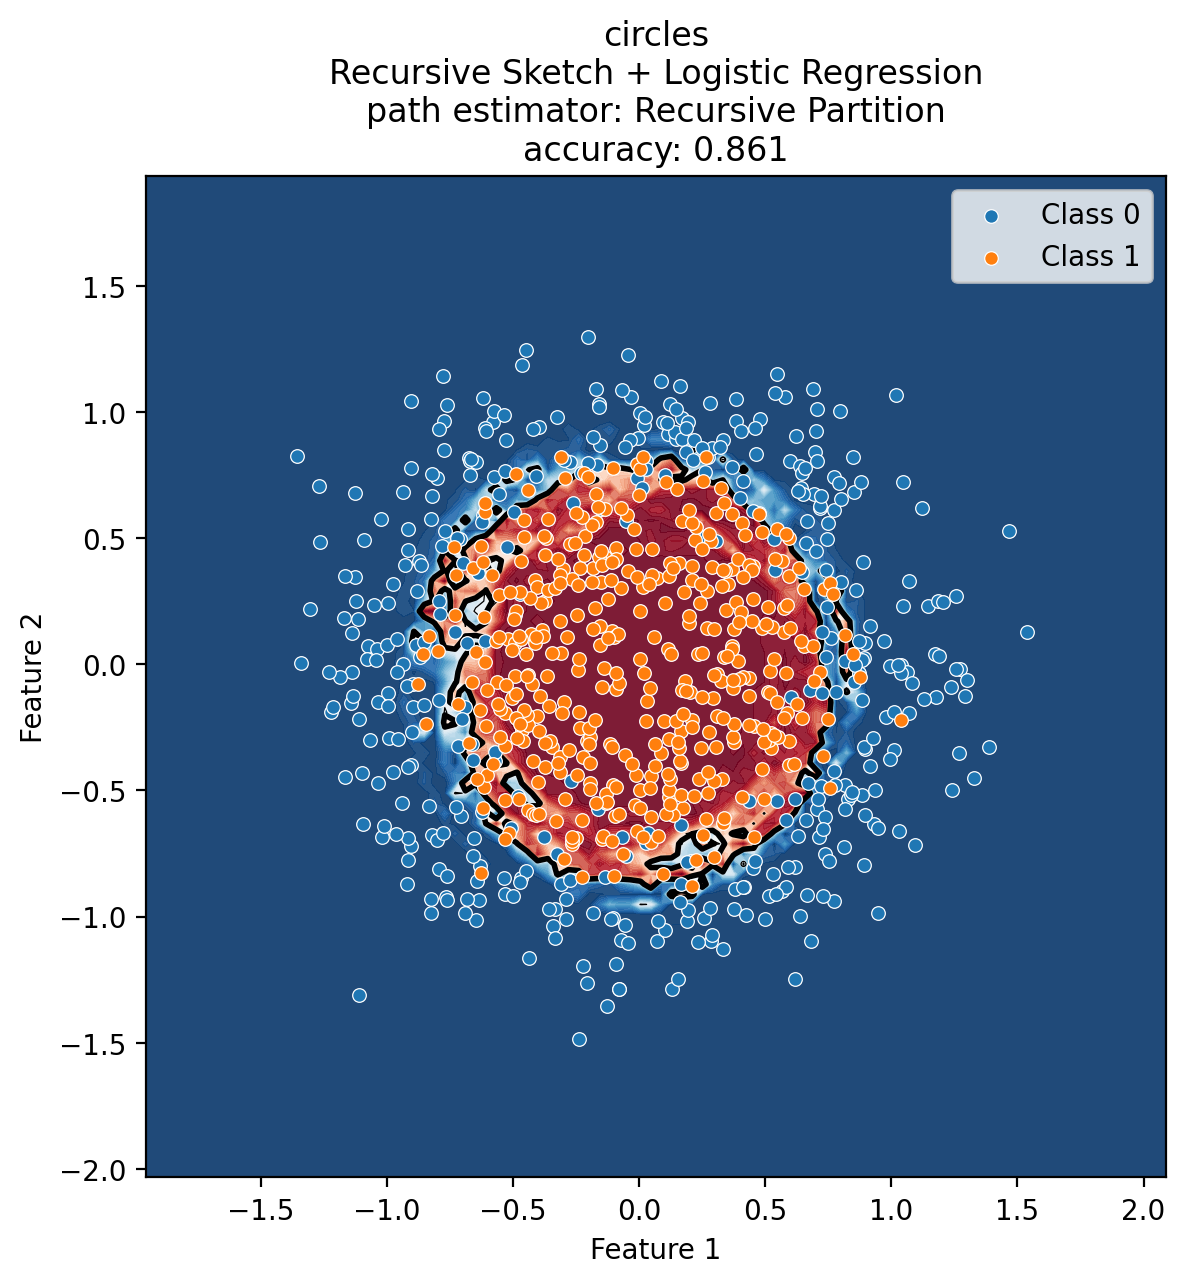

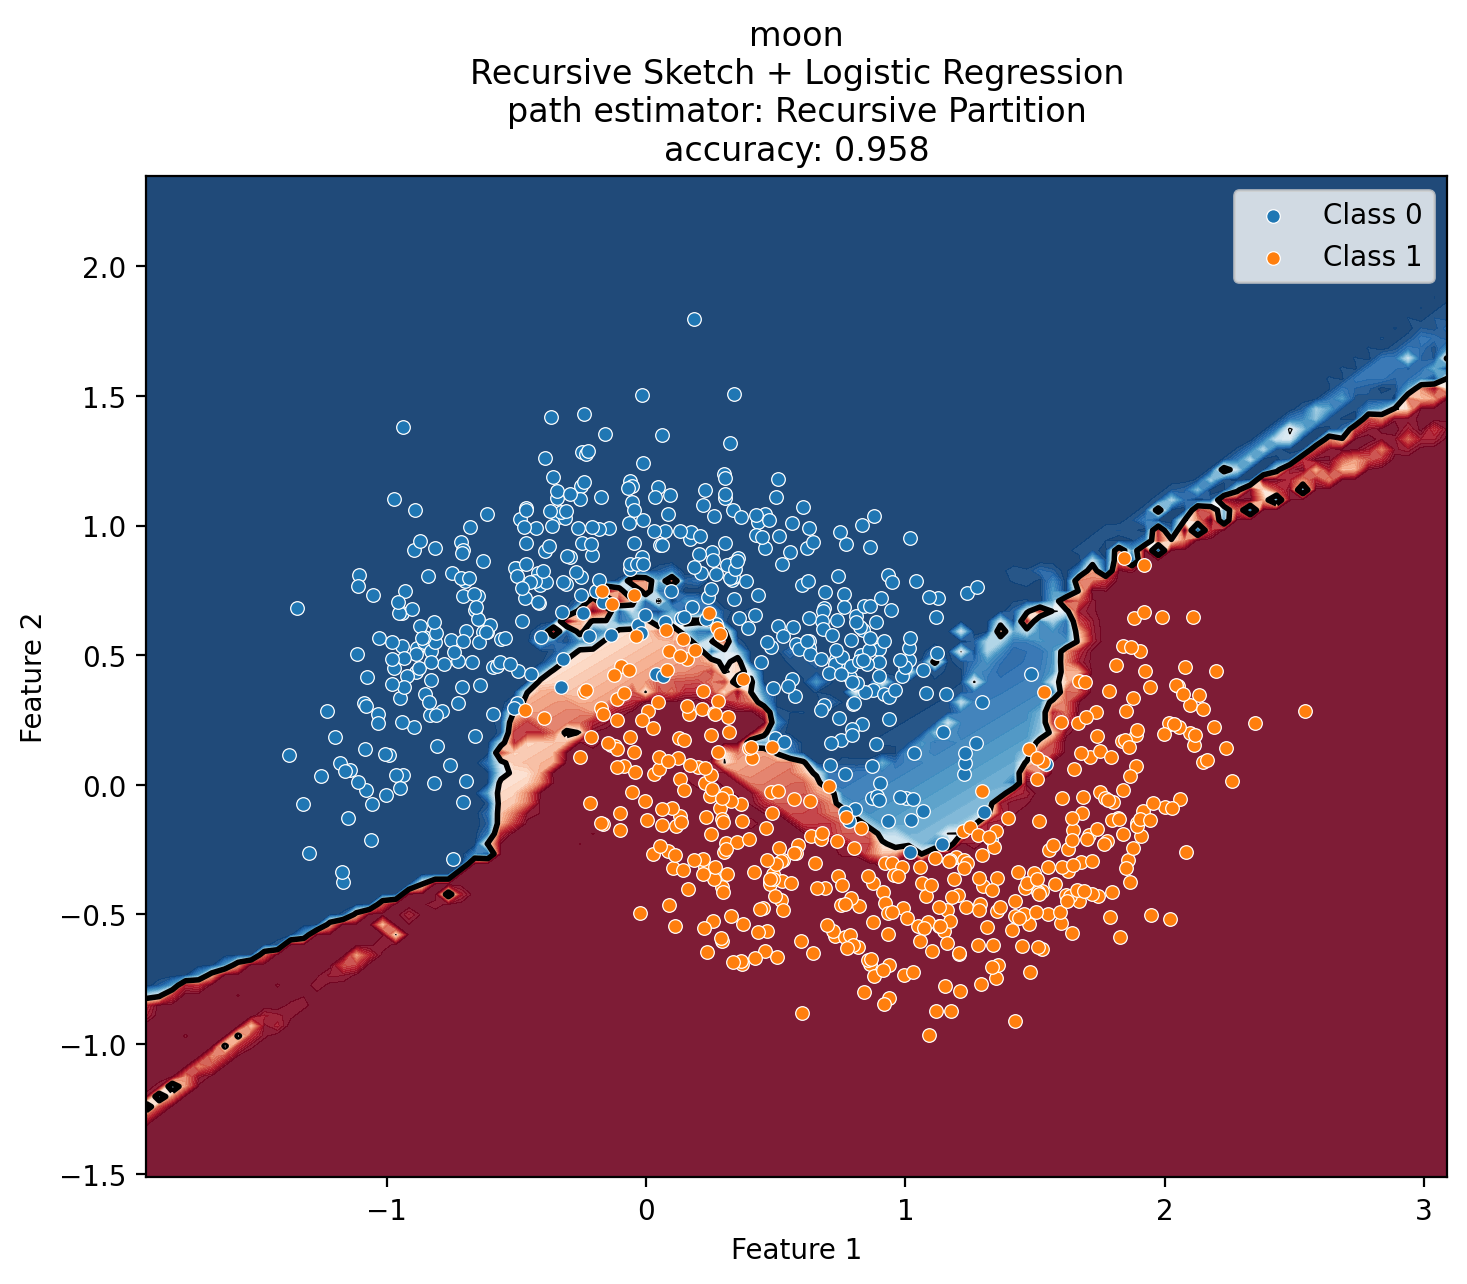

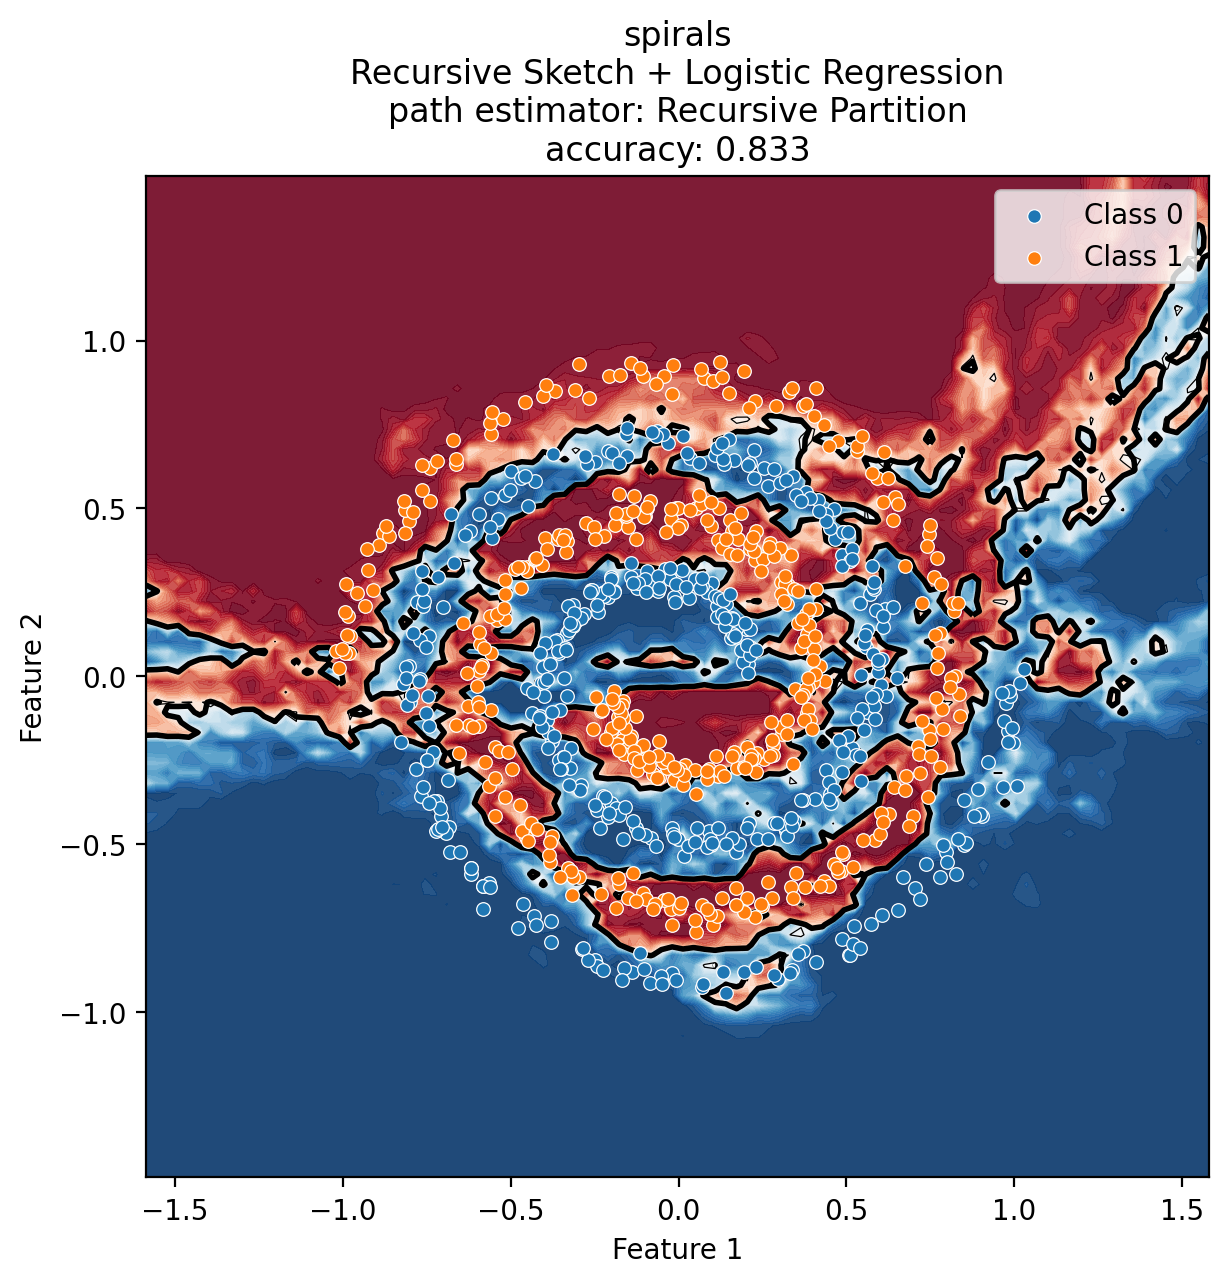

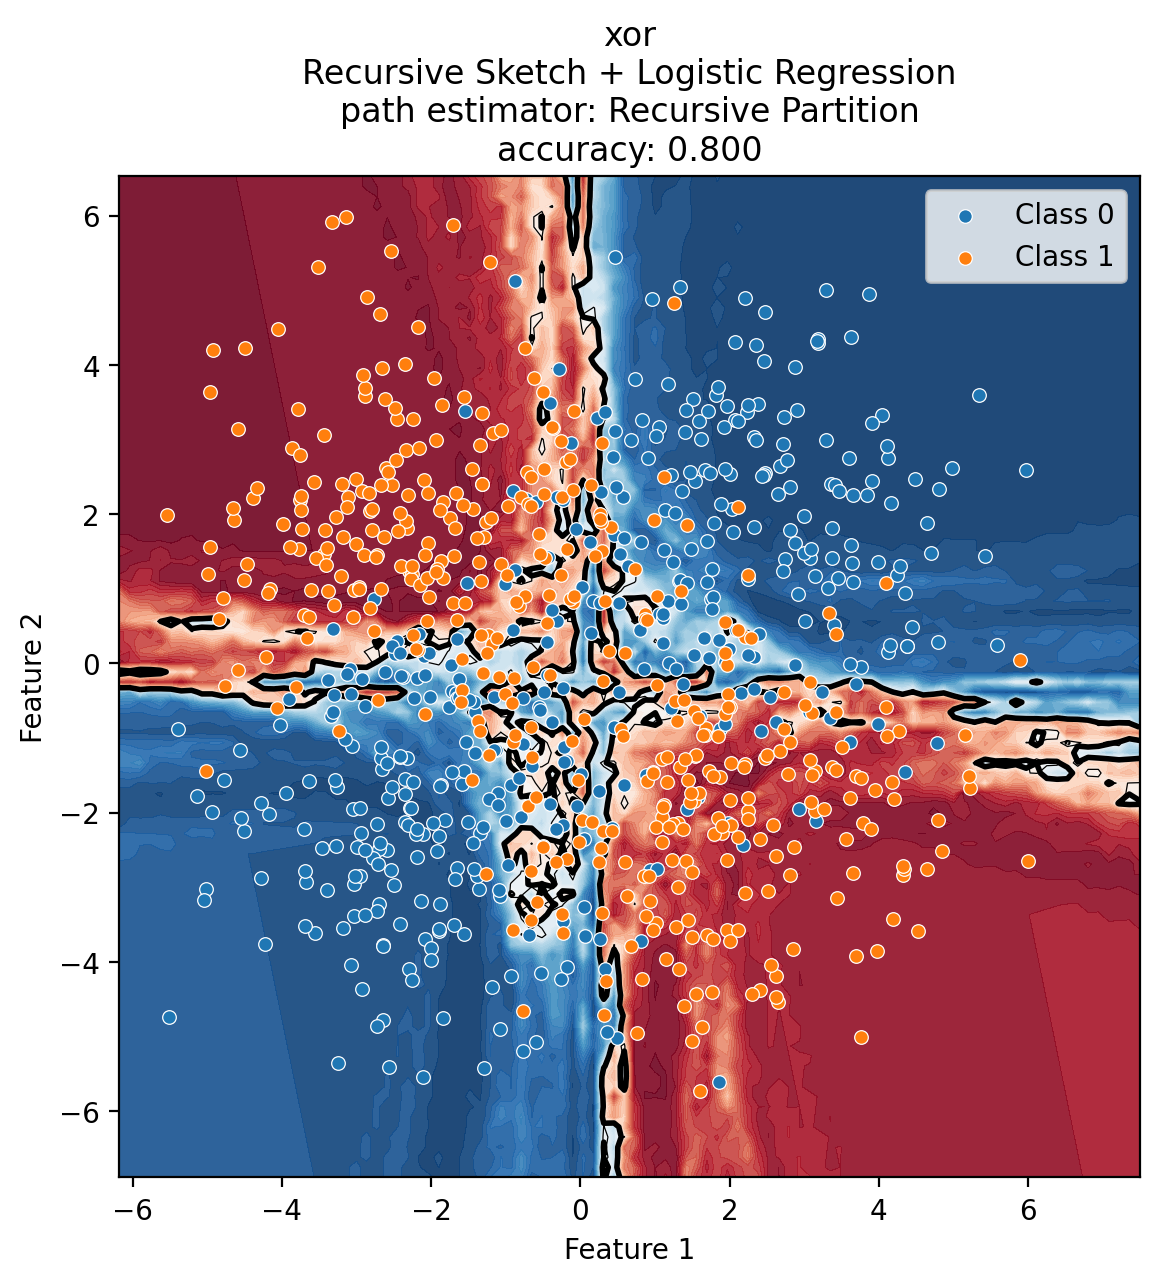

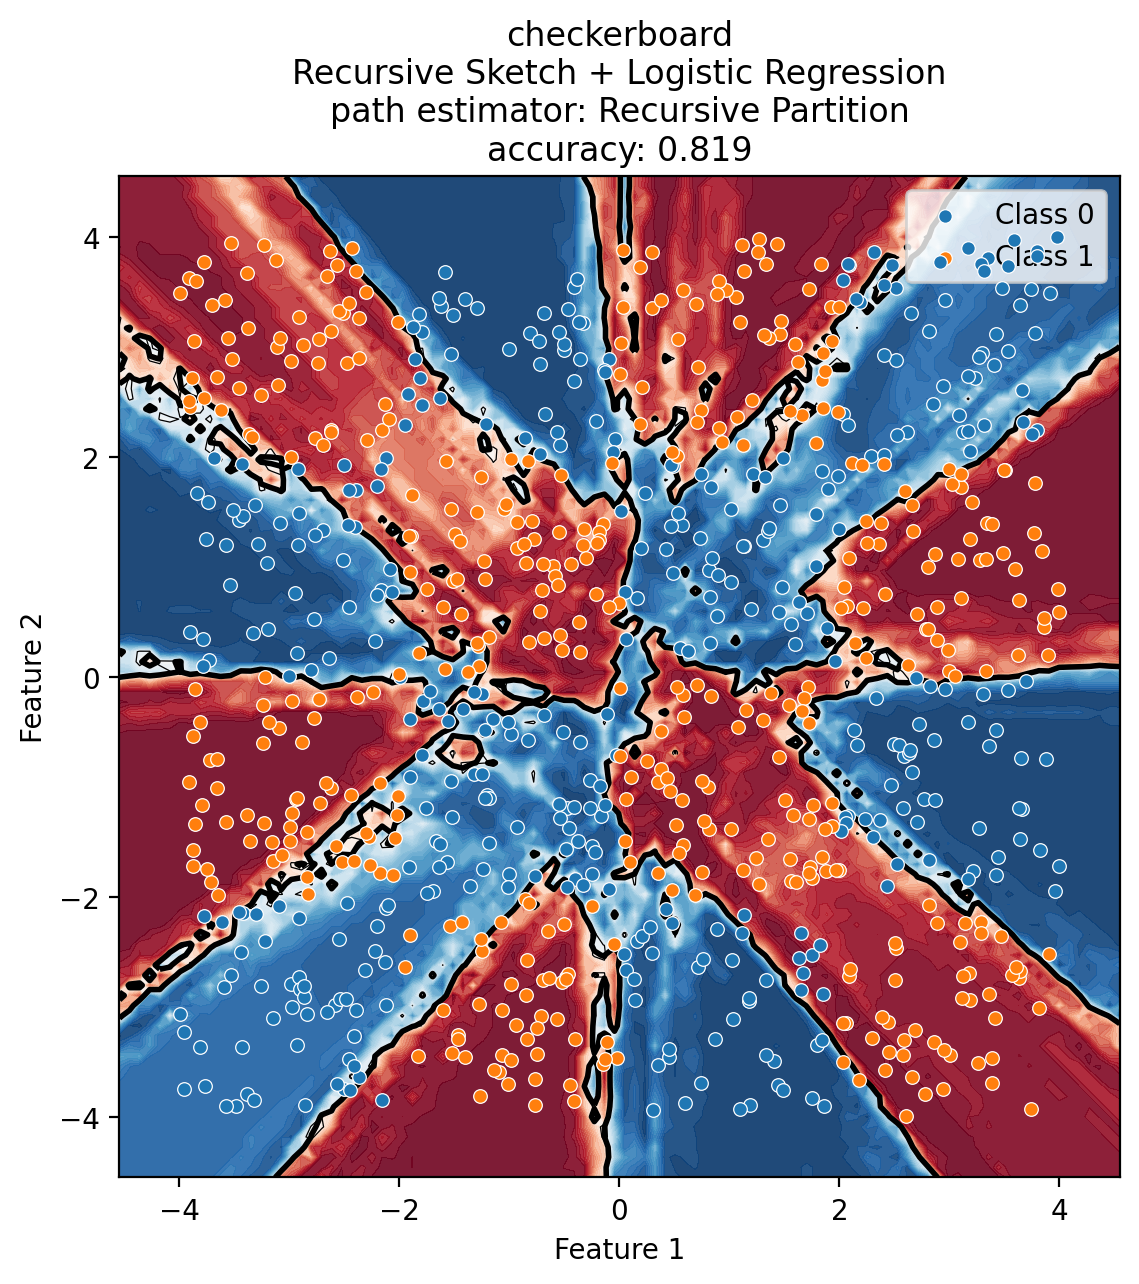

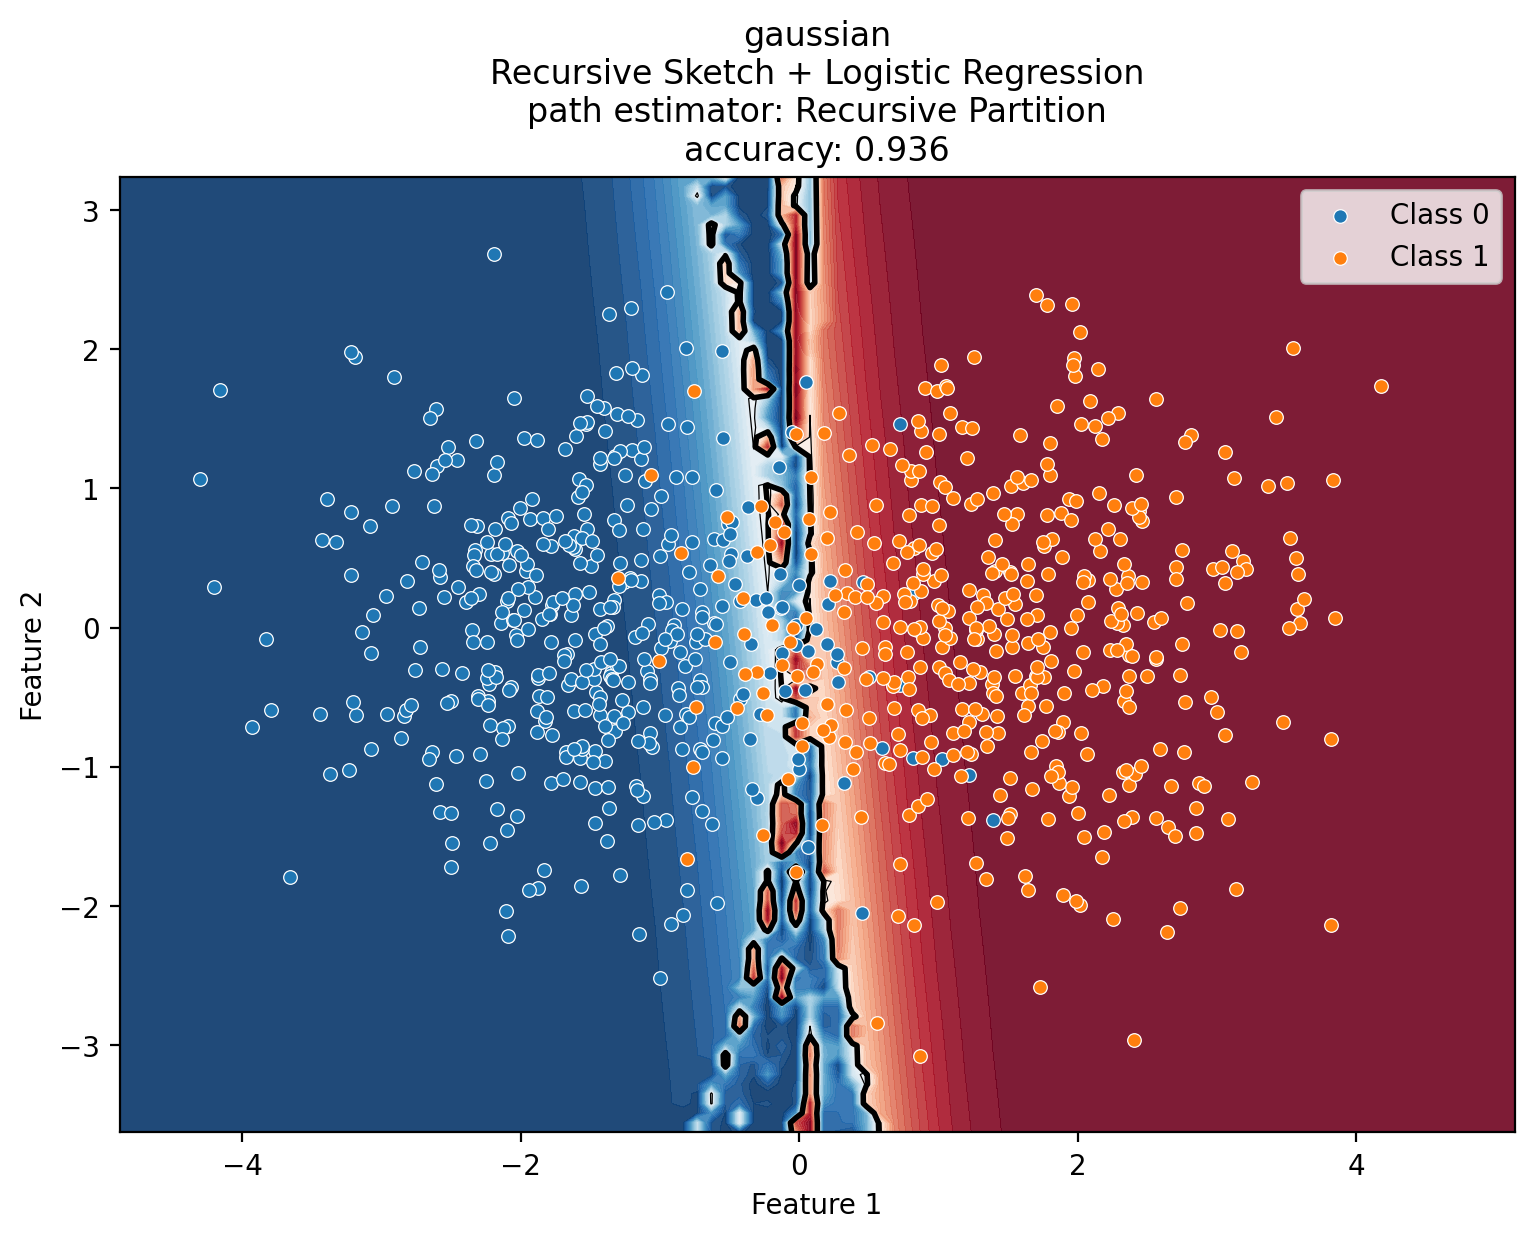

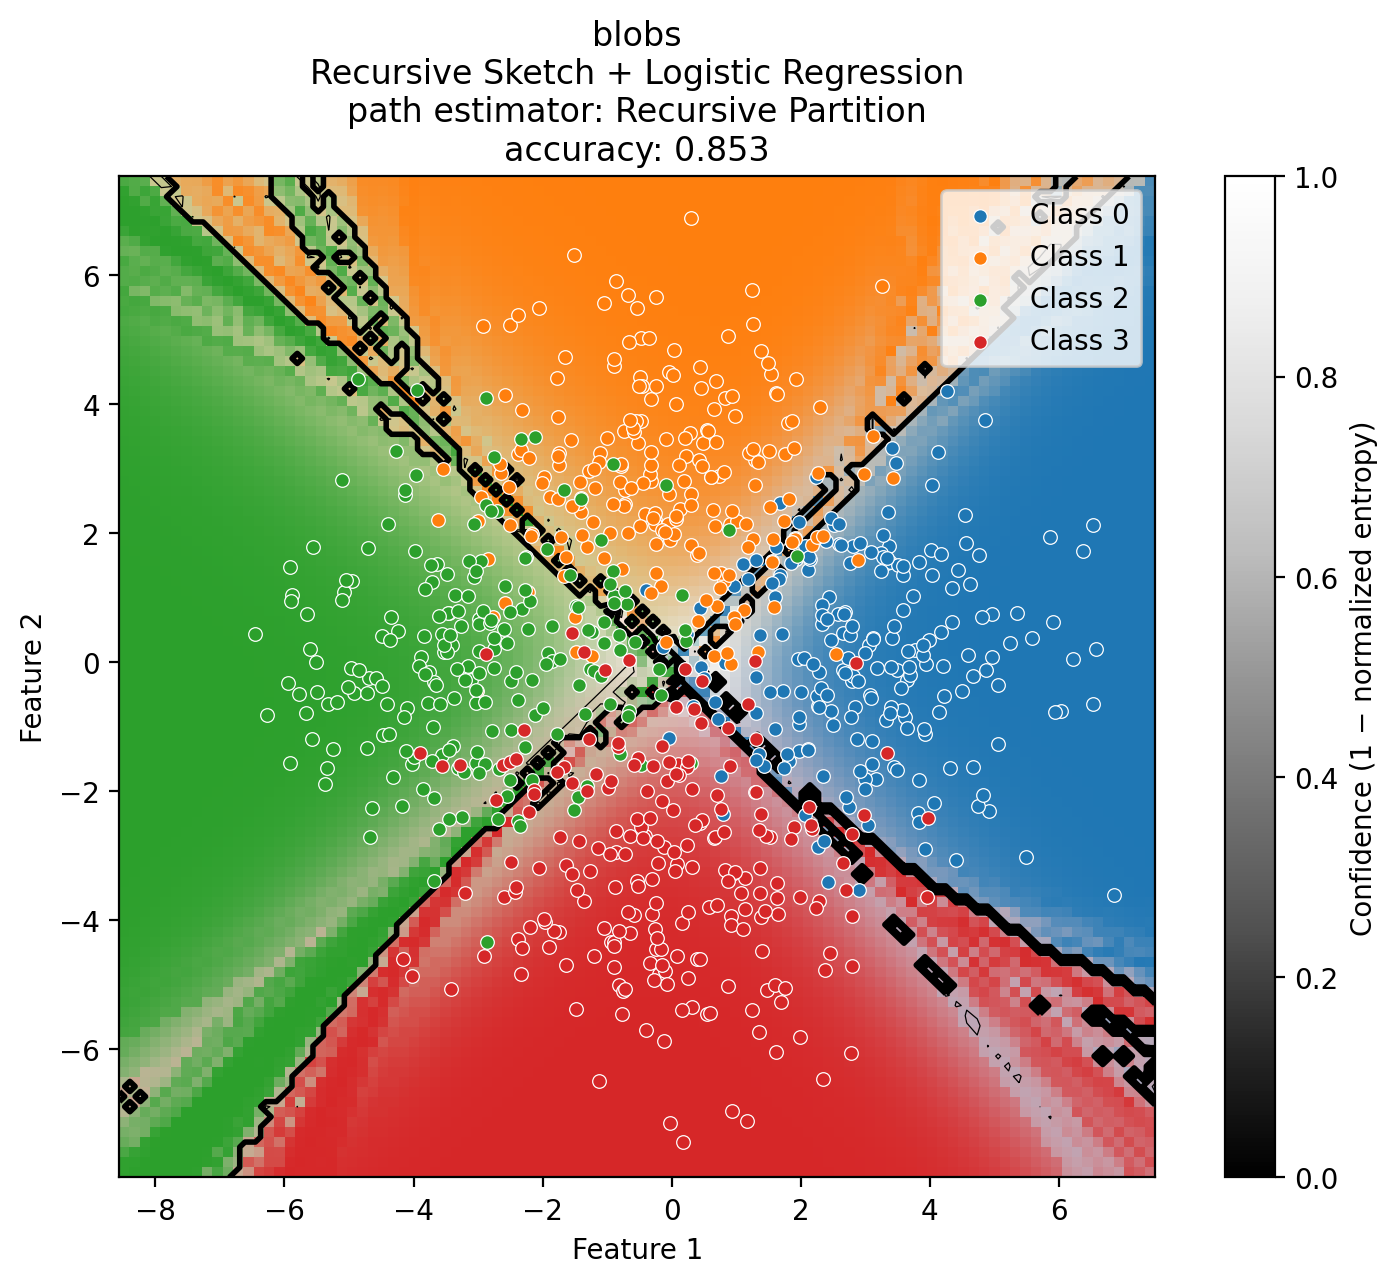

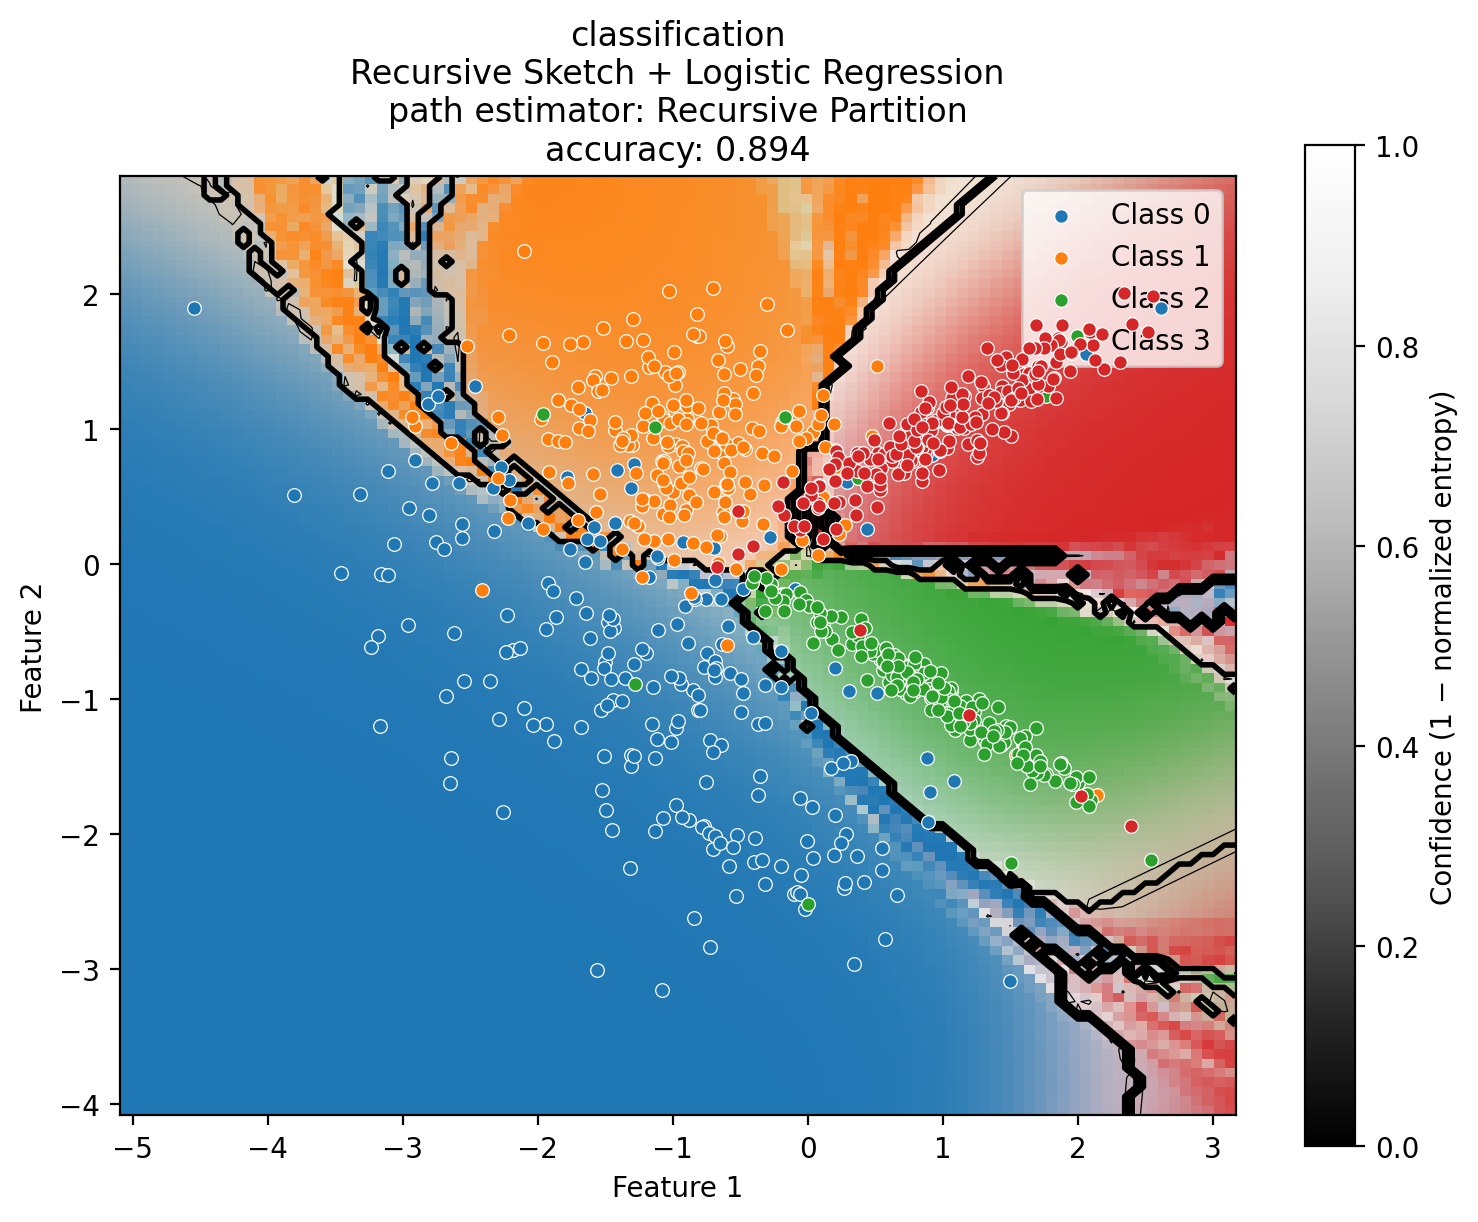

,dataset,path_estimator,accuracy,n_classes,output_dimension
0,circles,Recursive Partition,0.861,2,120
1,moon,Recursive Partition,0.958,2,120
2,spirals,Recursive Partition,0.833,2,120
3,xor,Recursive Partition,0.800,2,120
4,checkerboard,Recursive Partition,0.819,2,120
5,gaussian,Recursive Partition,0.936,2,120
6,blobs,Recursive Partition,0.853,4,120
7,classification,Recursive Partition,0.894,4,120


In [12]:
results, fitted_models = run_experiment(
    dataset_names=DATASET_NAMES,
    data_parameters=DATA_PARAMETERS,
    path_estimator=PATH_ESTIMATOR_KIND,
    sketch=SKETCH,
    classifier=CLASSIFIER,
    grid_size=GRID_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    show=True,
    return_models=True,
)
display(results.round({'accuracy': 3}))
# The fitted downstream classifier for a dataset is available as:
# fitted_models['circles'][-1]